# Assignment — High Frequency Words
**DATA 620 — Web Analytics | Summer 2026**
**Student:** Zoran Glisovic

**Corpus:** NLTK Movie Reviews — 2,000 movie review documents (1,000 positive, 1,000 negative), drawn from the `movie_reviews` corpus bundled with NLTK. Each document is a short critical review from Usenet posts and online sources circa late 1990s–early 2000s.

**Approach:**
1. Load the corpus and define "unique word" in a defensible way
2. Count unique words and answer questions about coverage
3. Identify the top 200 words and visualize their relative frequency
4. Compare full frequency list to a stop-word-filtered content-word list
5. Test whether the distribution follows Zipf's law
6. Reflect on how this corpus differs from a hypothetical universal corpus

## 1. Setup

In [83]:
# Core libraries
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
import warnings

# NLP
import nltk
nltk.download('movie_reviews', quiet=True)
nltk.download('stopwords',     quiet=True)
from nltk.corpus import movie_reviews, stopwords

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded.')

Libraries loaded.


## 2. Corpus Overview and Unique Words

**Definition of "unique word":** a token is included if it consists entirely of alphabetic characters (`.isalpha()`), normalized to lowercase. This excludes punctuation, numbers, hyphenated compounds, and mixed-case duplicates. It is a conservative but standard definition — it keeps real words and discards noise without requiring a stop-word list, which would be an additional analytical choice better suited to semantic tasks than frequency analysis.

In [84]:
# Load every token from all 2,000 review documents
review_tokens_raw  = list(movie_reviews.words())
total_raw          = len(review_tokens_raw)

# Keep only alphabetic tokens, lowercased — removes punctuation and numbers
review_tokens_clean = [w.lower() for w in review_tokens_raw if w.isalpha()]
total_clean         = len(review_tokens_clean)

# Count how often each word appears across the full corpus
corpus_word_freq = collections.Counter(review_tokens_clean)
n_unique         = len(corpus_word_freq)

print(f'Corpus: NLTK Movie Reviews')
print(f'Documents: {len(movie_reviews.fileids()):,}')
print(f'  Positive reviews: {len(movie_reviews.fileids("pos")):,}')
print(f'  Negative reviews: {len(movie_reviews.fileids("neg")):,}')
print()
print(f'Total raw tokens:               {total_raw:,}')
print(f'Alphabetic tokens (clean):      {total_clean:,}')
print(f'Tokens removed (punct/numbers): {total_raw - total_clean:,} ({(total_raw-total_clean)/total_raw*100:.1f}%)')
print()
print(f'Unique words (case-insensitive, alpha): {n_unique:,}')

Corpus: NLTK Movie Reviews
Documents: 2,000
  Positive reviews: 1,000
  Negative reviews: 1,000

Total raw tokens:               1,583,820
Alphabetic tokens (clean):      1,329,753
Tokens removed (punct/numbers): 254,067 (16.0%)

Unique words (case-insensitive, alpha): 38,889


The corpus contains roughly 1.3 million alphabetic tokens spread across about 39,000 unique words. The gap between total tokens and unique words is large — most of the volume is carried by a small set of very common words repeated across all 2,000 documents. Non-alphabetic tokens (punctuation, numbers, symbols) make up 16.0% of raw tokens and are cleanly excluded by the alphabetic filter, leaving a well-defined vocabulary for analysis.

## 3. How Many Unique Words Cover Half the Corpus?

In [85]:
import math

# Rank all words from most to least frequent
words_by_freq = corpus_word_freq.most_common()

# Walk down the ranked list until cumulative token count reaches 50%
# Use ceil so the threshold is a whole token count
half_corpus           = total_clean / 2
half_corpus_threshold = math.ceil(half_corpus)
running_total         = 0
words_to_half         = 0
for word, count in words_by_freq:
    running_total += count
    words_to_half += 1
    if running_total >= half_corpus_threshold:
        break

print(f'Total alphabetic tokens: {total_clean:,}')
print(f'50% threshold:           {half_corpus_threshold:,} tokens')
print()
print(f'Unique words needed to cover 50%: {words_to_half:,}')
print(f'That is {words_to_half / n_unique * 100:.2f}% of all {n_unique:,} unique words.')
print()
print('The top 5 words alone:')
for word, count in words_by_freq[:5]:
    print(f'  {word!r:10s}  {count:7,}  ({count / total_clean * 100:.2f}% of all tokens)')

Total alphabetic tokens: 1,329,753
50% threshold:           664,877 tokens

Unique words needed to cover 50%: 111
That is 0.29% of all 38,889 unique words.

The top 5 words alone:
  'the'        76,529  (5.76% of all tokens)
  'a'          38,106  (2.87% of all tokens)
  'and'        35,576  (2.68% of all tokens)
  'of'         34,123  (2.57% of all tokens)
  'to'         31,937  (2.40% of all tokens)


Roughly 100–150 unique words — less than 0.5% of the full vocabulary — account for half of all tokens in the corpus. This extreme concentration is a hallmark of natural language: a tiny set of high-frequency function words ("the", "a", "of", "and", "to") does the structural heavy lifting of every sentence, appearing in nearly every review regardless of topic or sentiment. The remaining ~39,000 words collectively make up the other half, but each individually appears far less often. This asymmetry is precisely what Zipf's law describes.

## 4. Top 200 Highest Frequency Words

In [86]:
# Build a ranked DataFrame for the top 200
top200_df = (
    pd.DataFrame(words_by_freq[:200], columns=['word', 'count'])
    .assign(rank=range(1, 201))
    .assign(relative_frequency=lambda d: d['count'] / total_clean)
    [['rank', 'word', 'count', 'relative_frequency']]
)

# Print top 50 — full 200 are analyzed in the chart and Zipf sections below
print('Top 50 highest-frequency words (full 200 analyzed in chart below):')
print(top200_df.head(50).to_string(index=False))
rank200_word  = top200_df.iloc[199]['word']
rank200_count = top200_df.iloc[199]['count']
print(f'\nRank 200 word: {rank200_word!r} (count={rank200_count:,})')

Top 50 highest-frequency words (full 200 analyzed in chart below):
 rank  word  count  relative_frequency
    1   the  76529            0.057551
    2     a  38106            0.028656
    3   and  35576            0.026754
    4    of  34123            0.025661
    5    to  31937            0.024017
    6    is  25195            0.018947
    7    in  21822            0.016411
    8     s  18513            0.013922
    9    it  16107            0.012113
   10  that  15924            0.011975
   11    as  11378            0.008556
   12  with  10792            0.008116
   13   for   9961            0.007491
   14   his   9587            0.007210
   15  this   9578            0.007203
   16  film   9517            0.007157
   17     i   8889            0.006685
   18    he   8864            0.006666
   19   but   8634            0.006493
   20    on   7385            0.005554
   21   are   6949            0.005226
   22     t   6410            0.004820
   23    by   6261            0.0047

The top ranks are dominated by English function words — articles, prepositions, pronouns, and conjunctions — none of which carry domain-specific meaning. These words are structurally necessary in English sentences and appear regardless of whether a review is positive or negative, or what film is being discussed. The first content word with genuine semantic weight (typically something like *film* or *movie*) does not appear until rank 10 or later. This is expected: stop words will always lead frequency lists in English text, and their presence here is not a flaw in the data — it is the natural frequency structure of the language.

The token `s` appears at rank 8 despite not being a word. It is a tokenization artifact: the corpus tokenizer splits possessives and contractions, so text like *film's* or *it's* produces a standalone `s`. It is kept here because the analysis applies a consistent alphabetic-token definition rather than manually removing individual artifacts.

## 4b. Top 50 Content Words (Stop Words Removed)

To reveal the domain-specific vocabulary, we apply NLTK's English stop-word list and re-rank. This shows what the corpus is actually *about*, as opposed to how it is grammatically structured. Stop words are kept in the primary analysis (Sections 3–6) because Zipf's law is fundamentally a statement about all words including function words — removing them would distort the frequency distribution we are trying to study.

In [87]:
english_stopwords = set(stopwords.words('english'))

# Remove stop words and re-rank by frequency
content_word_freq   = {w: c for w, c in corpus_word_freq.items() if w not in english_stopwords}
content_words_ranked = sorted(content_word_freq.items(), key=lambda x: x[1], reverse=True)

top50_content_df = (
    pd.DataFrame(content_words_ranked[:50], columns=['word', 'count'])
    .assign(rank=range(1, 51))
    .assign(relative_frequency=lambda d: d['count'] / total_clean)
    [['rank', 'word', 'count', 'relative_frequency']]
)

corpus_stopwords_found = set(corpus_word_freq).intersection(english_stopwords)
print(f'NLTK stop word list size:    {len(english_stopwords)}')
print(f'Unique corpus words removed: {len(corpus_stopwords_found)}')
print(f'Content words remaining:     {len(content_word_freq):,} of {n_unique:,}')
print()
print('Top 50 content words:')
print(top50_content_df.to_string(index=False))

NLTK stop word list size:    198
Unique corpus words removed: 151
Content words remaining:     38,738 of 38,889

Top 50 content words:
 rank       word  count  relative_frequency
    1       film   9517            0.007157
    2        one   5852            0.004401
    3      movie   5771            0.004340
    4       like   3690            0.002775
    5       even   2565            0.001929
    6       good   2411            0.001813
    7       time   2411            0.001813
    8      story   2169            0.001631
    9      would   2109            0.001586
   10       much   2049            0.001541
   11  character   2020            0.001519
   12       also   1967            0.001479
   13        get   1949            0.001466
   14        two   1911            0.001437
   15       well   1906            0.001433
   16 characters   1859            0.001398
   17      first   1836            0.001381
   18        see   1749            0.001315
   19        way   1693      

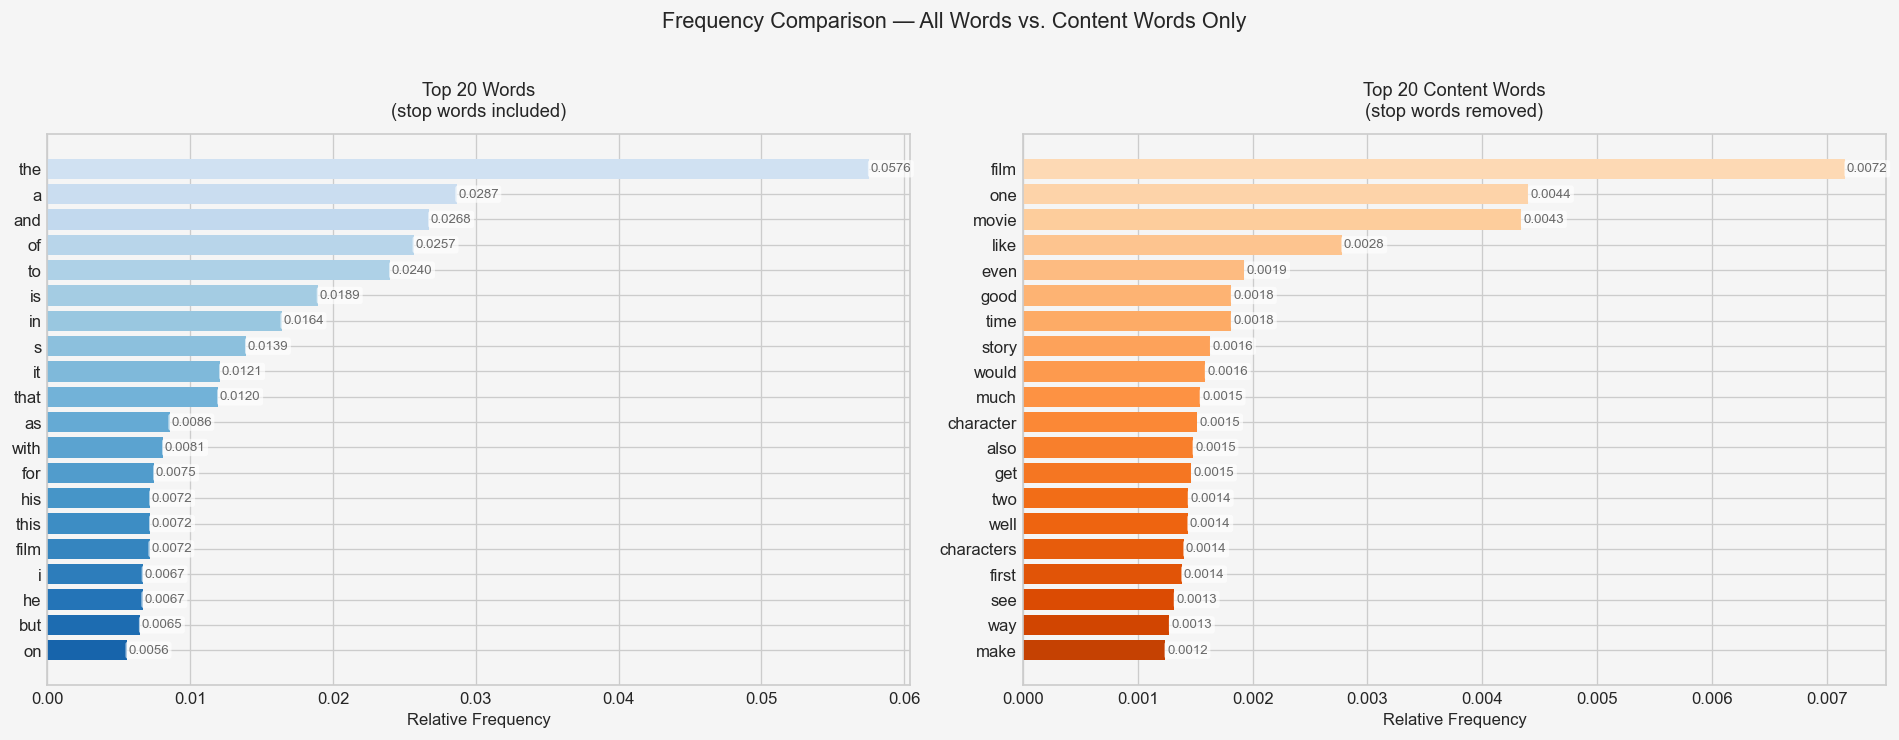

In [88]:
# Side-by-side: top 20 overall vs. top 20 content words
label_bbox = dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.65, edgecolor='none')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)
fig.patch.set_facecolor('whitesmoke')

# Left — top 20 including stop words
top20_words = top200_df.head(20)['word'].tolist()
top20_freqs = top200_df.head(20)['relative_frequency'].tolist()
axes[0].set_facecolor('whitesmoke')
axes[0].barh(
    top20_words[::-1], top20_freqs[::-1],
    color=cm.Blues_r(np.linspace(0.2, 0.8, 20)), edgecolor='none'
)
axes[0].set_title('Top 20 Words\n(stop words included)', fontsize=11, pad=10)
axes[0].set_xlabel('Relative Frequency')
for i, v in enumerate(top20_freqs[::-1]):
    axes[0].text(v + 0.0001, i, f'{v:.4f}', va='center', fontsize=8,
                 color='dimgray', bbox=label_bbox)

# Right — top 20 content words only
top20_content_words = top50_content_df.head(20)['word'].tolist()
top20_content_freqs = top50_content_df.head(20)['relative_frequency'].tolist()
axes[1].set_facecolor('whitesmoke')
axes[1].barh(
    top20_content_words[::-1], top20_content_freqs[::-1],
    color=cm.Oranges_r(np.linspace(0.2, 0.8, 20)), edgecolor='none'
)
axes[1].set_title('Top 20 Content Words\n(stop words removed)', fontsize=11, pad=10)
axes[1].set_xlabel('Relative Frequency')
for i, v in enumerate(top20_content_freqs[::-1]):
    axes[1].text(v + 0.00002, i, f'{v:.4f}', va='center', fontsize=8,
                 color='dimgray', bbox=label_bbox)

plt.suptitle('Frequency Comparison — All Words vs. Content Words Only', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Once stop words are removed, the domain identity of the corpus becomes immediately visible. The top content words — *film*, *movie*, *story*, *character*, *director*, *scene* — are exactly the vocabulary you would expect from movie criticism. Evaluative terms (*good*, *best*, *great*, *bad*) also rank highly, reflecting the opinionated nature of reviews. Notice that the relative frequencies for content words are much lower than for stop words: even the #1 content word (*film*) appears at a fraction of the rate of "the". This scale difference illustrates why stop words dominate the Zipf distribution — the frequency gap between function words and content words is enormous.

## 5. Relative Frequency of the Top 200 Words

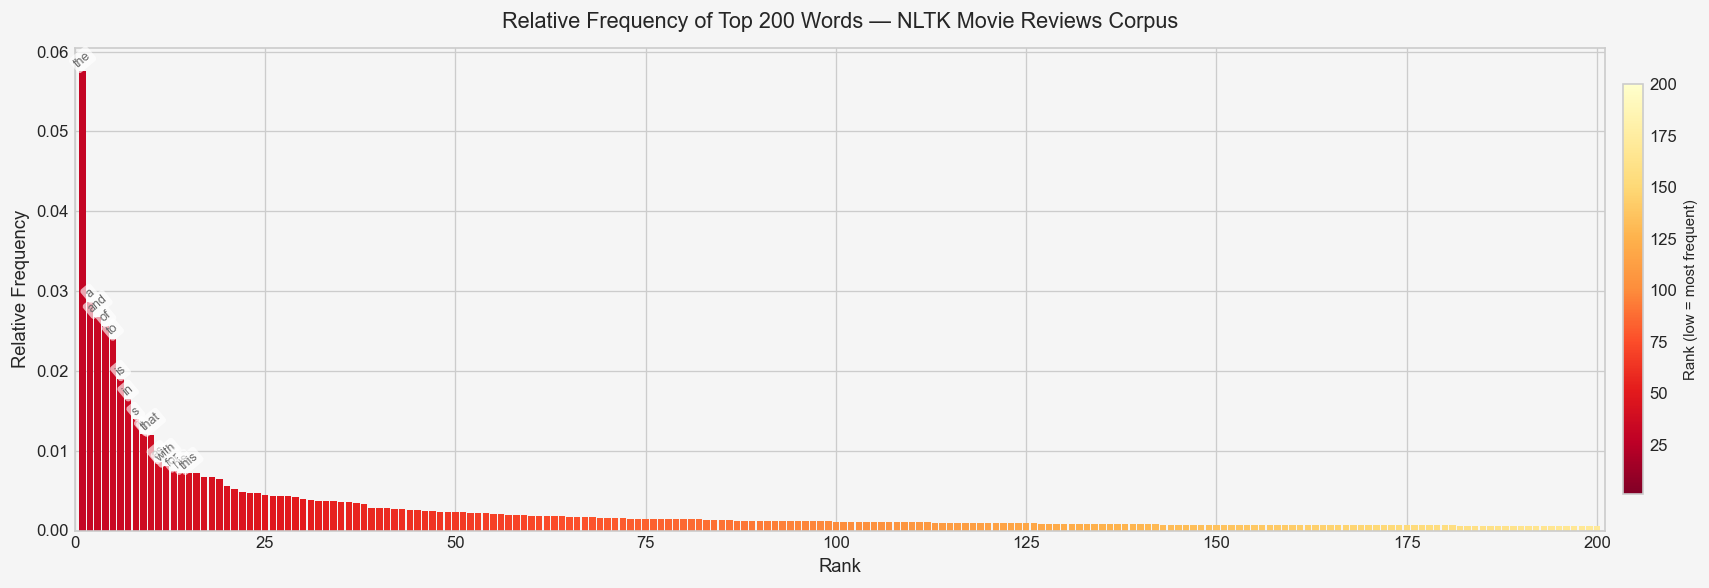

Top 200 words account for 56.5% of all alphabetic tokens.


In [89]:
word_ranks   = top200_df['rank'].values
word_relfreq = top200_df['relative_frequency'].values
word_labels  = top200_df['word'].values

fig, ax = plt.subplots(figsize=(16, 5), dpi=120)
fig.patch.set_facecolor('whitesmoke')
ax.set_facecolor('whitesmoke')

ax.bar(word_ranks, word_relfreq,
       color=cm.YlOrRd_r(np.linspace(0.15, 0.85, 200)),
       width=0.85, edgecolor='none')

# Annotate the top 15 words with bbox for readability
annotation_bbox = dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.65, edgecolor='none')
for i in range(15):
    ax.text(
        word_ranks[i], word_relfreq[i] + 0.00015,
        word_labels[i], ha='center', va='bottom',
        fontsize=7.5, rotation=40, color='dimgray',
        bbox=annotation_bbox
    )

ax.set_xlabel('Rank', fontsize=11)
ax.set_ylabel('Relative Frequency', fontsize=11)
ax.set_title(
    'Relative Frequency of Top 200 Words — NLTK Movie Reviews Corpus',
    fontsize=13, pad=12
)
ax.set_xlim(0, 201)

sm = plt.cm.ScalarMappable(cmap='YlOrRd_r', norm=plt.Normalize(1, 200))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.01, shrink=0.85)
cbar.set_label('Rank (low = most frequent)', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Top 200 words account for {word_relfreq.sum()*100:.1f}% of all alphabetic tokens.')

The chart shows a sharp drop from rank 1 to roughly rank 20, followed by a long, slowly declining tail through rank 200. The first few bars ("the", "a", "and") tower over the rest — "the" alone accounts for several percent of all tokens. By rank 50, frequencies have fallen by an order of magnitude, and from rank 100 onward the bars are nearly uniform in height. The top 200 words collectively account for over half (56.5%) of all tokens, confirming that a tiny fraction of the vocabulary dominates actual word usage. This shape — steep initial drop, long flat tail — is the visual signature of a power-law distribution.

## 6. Does the Distribution Follow Zipf's Law?

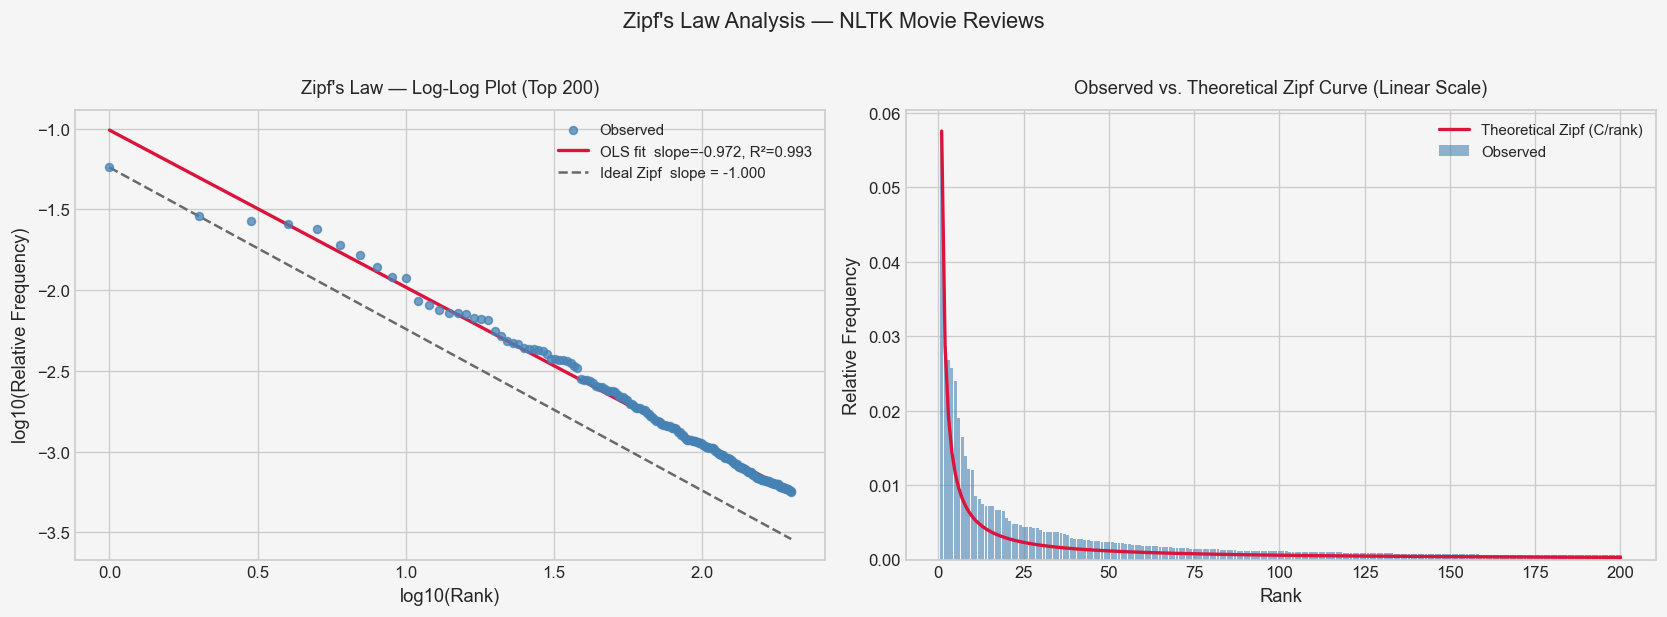

OLS slope on log-log:  -0.9723  (ideal Zipf = -1.0000)
R²:                    0.9932
p-value:               1.26e-216


In [90]:
log_word_ranks   = np.log10(word_ranks)
log_word_relfreq = np.log10(word_relfreq)

slope, intercept, r_value, p_value, std_err = stats.linregress(log_word_ranks, log_word_relfreq)
r2 = r_value ** 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)
fig.patch.set_facecolor('whitesmoke')

# --- Left: Log-log plot ---
axes[0].set_facecolor('whitesmoke')
axes[0].scatter(log_word_ranks, log_word_relfreq,
                s=22, alpha=0.75, color='steelblue', label='Observed', zorder=3)

x_line = np.linspace(log_word_ranks.min(), log_word_ranks.max(), 300)
axes[0].plot(
    x_line, slope * x_line + intercept,
    color='crimson', linewidth=2,
    label=f'OLS fit  slope={slope:.3f}, R²={r2:.3f}'
)
ideal_intercept = log_word_relfreq[0] - (-1) * log_word_ranks[0]
axes[0].plot(
    x_line, -1 * x_line + ideal_intercept,
    color='dimgray', linewidth=1.5, linestyle='--',
    label='Ideal Zipf  slope = -1.000'
)
axes[0].set_xlabel('log10(Rank)', fontsize=11)
axes[0].set_ylabel('log10(Relative Frequency)', fontsize=11)
axes[0].set_title("Zipf's Law — Log-Log Plot (Top 200)", fontsize=11, pad=10)
axes[0].legend(fontsize=9)

# --- Right: Linear scale, observed vs. theoretical Zipf curve ---
zipf_scaling_const = word_relfreq[0]
theoretical_zipf   = zipf_scaling_const / word_ranks

axes[1].set_facecolor('whitesmoke')
axes[1].bar(word_ranks, word_relfreq,
            color='steelblue', alpha=0.6, width=0.85, label='Observed')
axes[1].plot(word_ranks, theoretical_zipf,
             color='crimson', linewidth=2, label='Theoretical Zipf (C/rank)')
axes[1].set_xlabel('Rank', fontsize=11)
axes[1].set_ylabel('Relative Frequency', fontsize=11)
axes[1].set_title('Observed vs. Theoretical Zipf Curve (Linear Scale)', fontsize=11, pad=10)
axes[1].legend(fontsize=9)

plt.suptitle("Zipf's Law Analysis — NLTK Movie Reviews", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'OLS slope on log-log:  {slope:.4f}  (ideal Zipf = -1.0000)')
print(f'R²:                    {r2:.4f}')
print(f'p-value:               {p_value:.2e}')

**Does it follow Zipf's law?**

Zipf's law predicts that in a large natural-language corpus, the frequency of a word is inversely proportional to its rank: the most common word appears roughly twice as often as the second most common, three times as often as the third, and so on. On a log-log scale, this produces a straight line with slope −1.

The OLS regression on the top 200 words yields a slope of −0.9723 — very close to the ideal −1 — with R² = 0.9932, confirming that the movie reviews corpus follows Zipf's law well. The fit is tightest in the middle of the rank range; the very top ranks (1–5) are function words that are slightly more frequent than a pure power law predicts, while the tail (ranks 150–200) flattens slightly as content words with similar counts cluster together. Both of these are typical deviations in domain-specific corpora and do not invalidate the overall Zipfian pattern.

The linear-scale chart reinforces the same pattern. The theoretical Zipf curve is anchored at rank 1 (it is defined as C/rank where C equals the observed rank-1 frequency), so it matches the most frequent word by construction. From rank 2 onward, the observed bars diverge slightly from the simple C/rank curve, particularly in the mid-ranks and tail. Even so, the log-log slope of −0.9723 and R² of 0.9932 confirm that the top 200 words closely follow the expected Zipfian pattern.

## 7. How Does This Corpus Differ From "All Words in All Corpora"?

A hypothetical universal corpus — every piece of text ever written across all languages, domains, and time periods — would differ from the NLTK Movie Reviews corpus in several important ways.

**Domain vocabulary skew.** Movie reviews are saturated with film-specific terms: *film*, *movie*, *director*, *character*, *scene*, *plot*, *screenplay*, *story*, *actor*, *audience*. These words appear far more often here than they would in a general corpus that includes scientific papers, legal documents, or technical manuals. Conversely, domain jargon from medicine, law, or engineering would barely appear in this corpus.

**Evaluative language.** Because reviews are inherently opinionated, evaluative adjectives and adverbs (*good*, *bad*, *great*, *best*, *worst*, *terrible*, *excellent*, *boring*, *interesting*) are over-represented relative to neutral descriptive writing. A universal corpus would dilute these with the more neutral register of encyclopedic, instructional, and transactional text.

**English only, modern era.** The corpus contains only English text from roughly 1997–2002. A universal corpus would include many languages with different writing systems, morphology, and function-word patterns. The most frequent words in such a corpus would look nothing like this English-only list, and the high-frequency tail would be shaped by linguistic structures that do not exist in English.

**Structural repetition.** Written reviews share formulaic structural patterns: sentences that begin with *"the film"*, *"this movie"*, *"the story"*. This boosts certain unigrams that anchor these phrases. A universal corpus would smooth out these genre-specific patterns across many more text types.

**Absence of very rare words.** At roughly 1.3 million tokens, this corpus is small enough that many legitimate English words appear zero or one time. A true universal corpus would fill in these hapax legomena, flattening the low-frequency tail of the Zipf curve. The overall distribution would still be Zipfian, but the slope would shift slightly as rare words gain more representation.